# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Dataset yang digunakan**: Rock Paper Scissors Dataset dari Dicoding.
Dataset ini berisi gambar tangan yang menunjukkan bentuk batu, gunting, dan kertas.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# Alternatif: Download dataset langsung di Colab
!wget --no-check-certificate https://github.com/dicodingacademy/assets/releases/download/release/rockpaperscissors.zip -O /tmp/rockpaperscissors.zip
!unzip -q /tmp/rockpaperscissors.zip -d /content/

dataset_path = '/content/rockpaperscissors/rps-cv-images'

print('Daftar kelas/folder:')
for kelas in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, kelas)):
        print(kelas)

--2026-06-08 23:36:43--  https://github.com/dicodingacademy/assets/releases/download/release/rockpaperscissors.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/391417272/7eb836f2-695b-4a46-9c78-b65867166957?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-09T00%3A31%3A27Z&rscd=attachment%3B+filename%3Drockpaperscissors.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-08T23%3A31%3A09Z&ske=2026-06-09T00%3A31%3A27Z&sks=b&skv=2018-11-09&sig=J8oeEHLD4k6oDiHiGxHJGxJL3bzdVi7LAQfR3pCy%2F0M%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MDk2NTQwNCwibmJmIjoxNzgwOTYxODA0LCJwYXRoIjoicmVsZWFzZWFz

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah gambar Rock: 726
Jumlah gambar Paper: 712
Jumlah gambar Scissors: 750


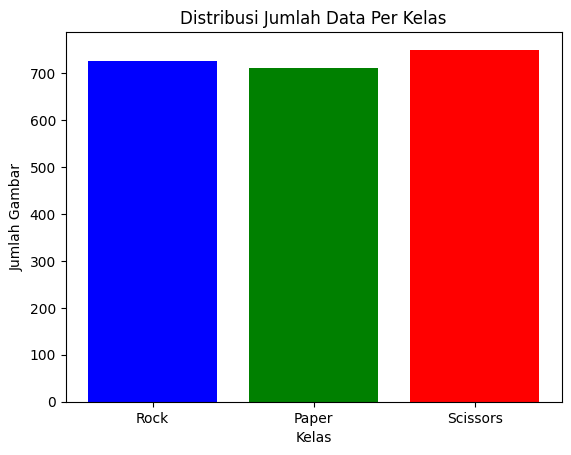

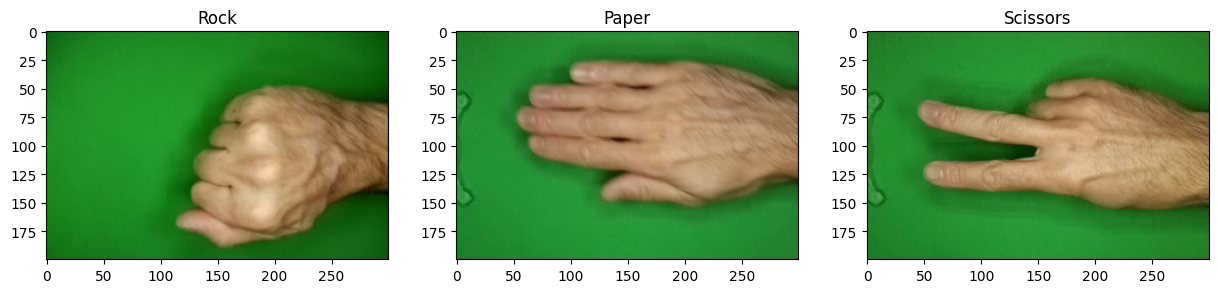

Ukuran gambar LlDkBm3uklZkHrB0.png: (200, 300, 3)
Ukuran gambar 77rce5yVvVPIPmp8.png: (200, 300, 3)
Ukuran gambar NCHfmPjxa7aay5AX.png: (200, 300, 3)


In [3]:
rock_dir = os.path.join(dataset_path, 'rock')
paper_dir = os.path.join(dataset_path, 'paper')
scissors_dir = os.path.join(dataset_path, 'scissors')

jml_rock = len(os.listdir(rock_dir))
jml_paper = len(os.listdir(paper_dir))
jml_scissors = len(os.listdir(scissors_dir))

print(f'Jumlah gambar Rock: {jml_rock}')
print(f'Jumlah gambar Paper: {jml_paper}')
print(f'Jumlah gambar Scissors: {jml_scissors}')

kelas = ['Rock', 'Paper', 'Scissors']
jumlah = [jml_rock, jml_paper, jml_scissors]

plt.bar(kelas, jumlah, color=['blue', 'green', 'red'])
plt.title('Distribusi Jumlah Data Per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

rock_img = os.path.join(rock_dir, os.listdir(rock_dir)[0])
paper_img = os.path.join(paper_dir, os.listdir(paper_dir)[0])
scissors_img = os.path.join(scissors_dir, os.listdir(scissors_dir)[0])

ax[0].imshow(mpimg.imread(rock_img))
ax[0].set_title('Rock')
ax[1].imshow(mpimg.imread(paper_img))
ax[1].set_title('Paper')
ax[2].imshow(mpimg.imread(scissors_img))
ax[2].set_title('Scissors')
plt.show()

sample_images = [rock_img, paper_img, scissors_img]
for img_path in sample_images:
    img = cv2.imread(img_path)
    print(f'Ukuran gambar {os.path.basename(img_path)}: {img.shape}')

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
IMG_SIZE = 128
data = []
labels = []

# rock = 0, paper = 1, scissors = 2
label_map = {'rock': 0, 'paper': 1, 'scissors': 2}

for kelas, label in label_map.items():
    kelas_dir = os.path.join(dataset_path, kelas)
    if not os.path.exists(kelas_dir): continue
    for file_name in os.listdir(kelas_dir):
        img_path = os.path.join(kelas_dir, file_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img_resized)
            labels.append(label)

data = np.array(data, dtype='float32') / 255.0
labels = np.array(labels)

print('Shape data:', data.shape)
print('Shape labels:', labels.shape)

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print('Shape X_train:', X_train.shape)
print('Shape X_test:', X_test.shape)

processed_dir = '/content/processed_dataset'
if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)

np.save(os.path.join(processed_dir, 'X_train.npy'), X_train)
np.save(os.path.join(processed_dir, 'X_test.npy'), X_test)
np.save(os.path.join(processed_dir, 'y_train.npy'), y_train)
np.save(os.path.join(processed_dir, 'y_test.npy'), y_test)

print('Hasil preprocessing berhasil disimpan di:', processed_dir)

Shape data: (2188, 128, 128, 3)
Shape labels: (2188,)
Shape X_train: (1750, 128, 128, 3)
Shape X_test: (438, 128, 128, 3)
Hasil preprocessing berhasil disimpan di: /content/processed_dataset
